In [1]:
import sys
import os
sys.path.append("../")
print(os.getcwd())
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import os
from datetime import datetime
from src.model import VAE  

latent_dim = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae_model_path = "../saved_models/vae20250407_212620_vae.pth"
vae = VAE(latent_dim=latent_dim).to(device)  # Match latent_dim to your model

checkpoint = torch.load(vae_model_path, map_location=device)
vae.load_state_dict(checkpoint['model_state_dict'])
vae.eval()  # Set to evaluation mode



/mnt/batch/tasks/shared/LS_root/mounts/clusters/jack-vm/code/Projects/Jack_ForceDeck_Winter_2024/countermovement-jump-analysis/scripts


/tmp/ipykernel_4559/4475400.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(vae_model_path, map_location=device)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
  )
  (mean_layer): Linear(in_features=64, out_features=4, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=4, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=100, bias=True)
  )
)

In [2]:
data = pd.read_pickle("../data/outlier_removed.pkl")  

In [3]:
import pandas as pd
import torch

data = pd.read_pickle("../data/outlier_removed.pkl")

downsampled_data = data['downsampled_time_series'].values

downsampled_tensor = torch.tensor(downsampled_data.tolist(), dtype=torch.float32).to(device)

def get_latent_vectors(vae, data_tensor):
    vae.eval()  
    with torch.no_grad():  
        encoder_output = vae.encoder(data_tensor)
        return encoder_output.cpu().numpy()

# add the latent vectors to the dataframe
latent_vectors = get_latent_vectors(vae, downsampled_tensor)

data['vae_latent_space'] = list(latent_vectors)

In [7]:
data

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,total_force,initial_value,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,outlier,initial_weight,vae_latent_space
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[519.4403179999999, 519.4403179999999, 516.440...",519.440318,"[1.0, 1.0, 0.994224553050578, 0.99422455305057...","[0.9997689723968506, 0.9933004975318909, 0.982...","[2.717329740524292, 1.7964253425598145, 0.9758...",0.309237,0.001501,0,519.440318,"[-0.024824915, -0.05880911, -0.0632134, 0.1535..."
2,2,2,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,3,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[520.440318, 518.440318, 517.440318, 517.44031...",520.440318,"[1.0, 0.9961571001883832, 0.9942356502825748, ...","[0.9965413808822632, 0.9969256520271301, 0.990...","[3.1668541431427, 1.8523129224777222, 0.724412...",0.129318,0.001124,0,520.440318,"[-0.030004127, -0.06468853, -0.07945599, 0.157..."
3,3,3,4a5363af-861a-47f9-ba52-c5f16d7888e4,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-06-01 14:05:48.427000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[521.874883, 522.874883, 521.874883, 520.87488...",521.874883,"[1.0, 1.0019161680942594, 1.0, 0.9980838319057...","[1.0014275312423706, 0.9956023693084717, 0.991...","[3.159482717514038, 1.2826811075210571, 0.7859...",0.266410,0.000903,0,521.874883,"[-0.029535756, -0.06887656, -0.0895605, 0.0963..."
4,4,4,4a5363af-861a-47f9-ba52-c5f16d7888e4,2,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-06-01 14:05:48.427000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[525.874883, 525.874883, 525.874883, 524.87488...",525.874883,"[1.0, 1.0, 1.0, 0.9980984069931326, 0.99619681...","[1.0, 0.9917470812797546, 0.9792250394821167, ...","[3.154348850250244, 1.2663376331329346, 1.0471...",0.119421,0.000868,0,525.874883,"[-0.027667174, -0.068688735, -0.093230486, 0.0..."
5,5,5,4a5363af-861a-47f9-ba52-c5f16d7888e4,3,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-06-01 14:05:48.427000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[525.874883, 523.874883, 523.874883, 522.87488...",525.874883,"[1.0, 0.9961968139862653, 0.9961968139862653, ...","[0.9961968064308167, 0.9845780730247498, 0.972...","[3.1080358028411865, 1.3878079652786255, 0.866...",0.151252,0.002650,0,525.874883,"[-0.028992003, -0.06562298, -0.085353695, 0.10..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30007,961,961,563dc37d-7c51-4148-be8f-de37995e40b2,2,b4082637-a999-481f-acdf-f0e920c4ac88,2025-02-10 16:09:56.957000+00:00,Women's Tennis,Sport,NaN,71.67,...,"[678.1093900000001, 673.1093900000001, 673.109...",678.109390,"[1.0, 0.99262655837873, 0.99262655837873, 0.98...","[0.9926265478134155, 0.976699948310852, 0.9601...","[3.2570815086364746, 1.8401820659637451, -0.31...",0.029429,0.000731,0,678.109390,"[-0.02151326, -0.06440966, -0.052515913, 0.200..."
30008,962,962,563dc37d-7c51-4148-be8f-de37995e40b2,3,b4082637-a999-481f-acdf-f0e920c4ac88,2025-02-10 16:09:56.957000+00:00,Women's Tennis,Sport,NaN,71.67,...,"[680.1093900000001, 682.1093900000001, 680.109...",680.109390,"[1.0, 1.0029407034065505, 1.0, 0.9985296482967...","[1.0016762018203735, 0.9848700761795044, 0.971...","[3.1179983615875244, 1.5908831357955933, -0.26...",0.088220,0.000255,0,680.109390,"[-0.02351613, -0.062360264, -0.05705451, 0.181..."
30009,963,963,5ede9122-b6e8-49cb-98d0-f681d00c30c1,1,b4082637-a999-481f-acdf-f0e920c4ac88,2025-02-17 16:07:22.849000+00:00,Women's Tennis,Sport,NaN,72.55,...,"[689.559535, 688.559535, 686.559535, 685.55953...",689.559535,"[1.0, 0.9985497988944494, 0.9956493966833481, ...","[0.9971141219139099, 0.9883983731269836, 0.981...","[2.8664588928222656, 1.292733907699585, -0.214...",0.055117,0.000363,0,689.559535,"[-0.023376556, -0.061202146, -0.059094798, 0.

In [4]:
def get_latent_stats(vae, data_tensor):
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return mean.cpu().numpy(), std.cpu().numpy(), z.cpu().numpy()


In [5]:
means, stds, latents = get_latent_stats(vae, downsampled_tensor)

In [11]:
def get_4d_latent_vectors(vae, data_tensor):
    """
    Encodes the data using VAE and returns 2D latent vectors.
    """
    vae.eval()
    with torch.no_grad():
        mean, logvar = vae.encode(data_tensor)
        std = torch.exp(0.5 * logvar)
        z = vae.reparameterization(mean, std)
    return z.cpu().numpy()

latent_vectors_4d = get_4d_latent_vectors(vae, downsampled_tensor)

data['vae_latent_space_4d'] = list(latent_vectors_4d)


In [12]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,outlier,initial_weight,vae_latent_space,vae_latent_space_2d,vae_latent_space_4d
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[1.0, 1.0, 0.994224553050578, 0.99422455305057...","[0.9997689723968506, 0.9933004975318909, 0.982...","[2.717329740524292, 1.7964253425598145, 0.9758...",0.309237,0.001501,0,519.440318,"[-0.024824915, -0.05880911, -0.0632134, 0.1535...","[0.45923862, 0.5638069, 1.921875, 0.08312285]","[-1.4384215, -0.39123285, 1.3975654, -0.08769328]"


In [14]:
import matplotlib.pyplot as plt

def plot_single_reconstruction(vae, data_tensor, index=2):
    vae.eval()
    with torch.no_grad():
        x = data_tensor[index].unsqueeze(0)  # batch dim
        x_hat, _, _ = vae(x)

    original = x.squeeze().cpu().numpy()
    reconstructed = x_hat.squeeze().cpu().numpy()

    plt.figure(figsize=(8, 6))
    plt.plot(original, label="Original", color="blue")
    plt.plot(reconstructed, label="Reconstructed", color="orange", linestyle='--')
    plt.title(f"Original vs Reconstructed - Jump Index: {index}")
    plt.xlabel("Step")
    plt.ylabel("Force")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


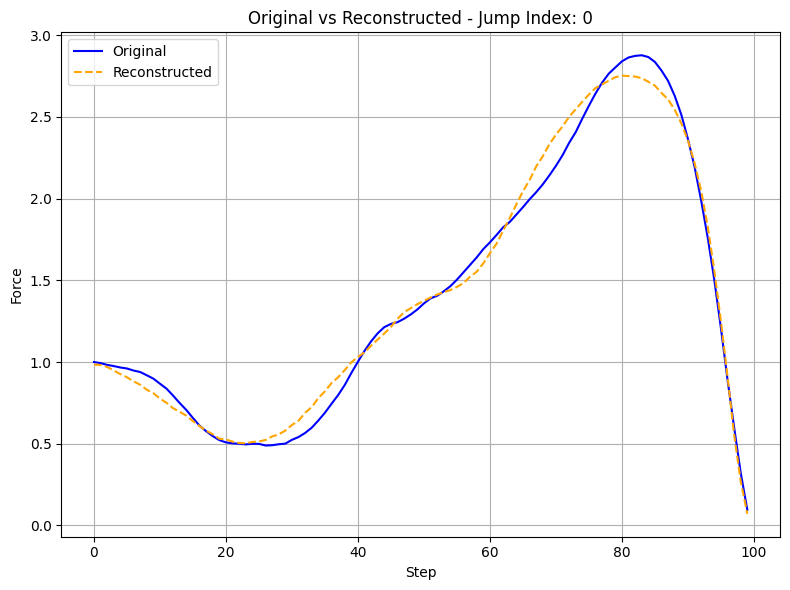

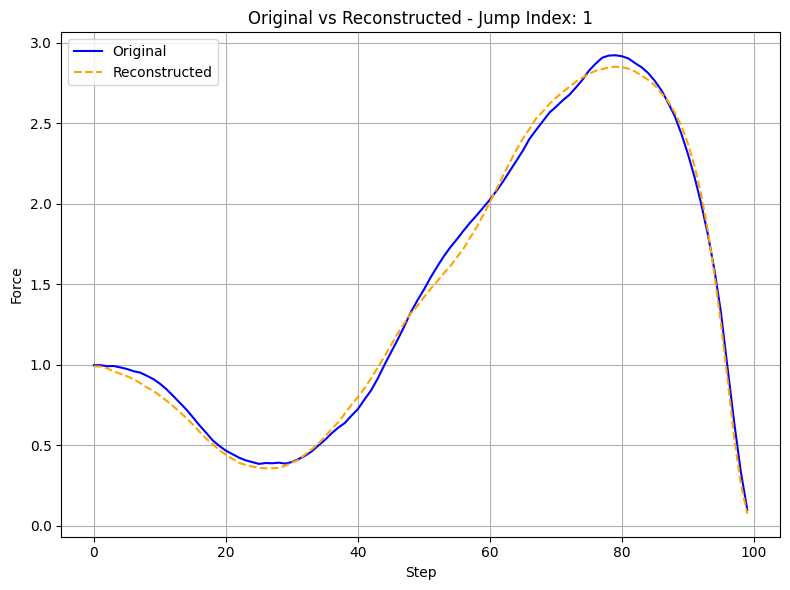

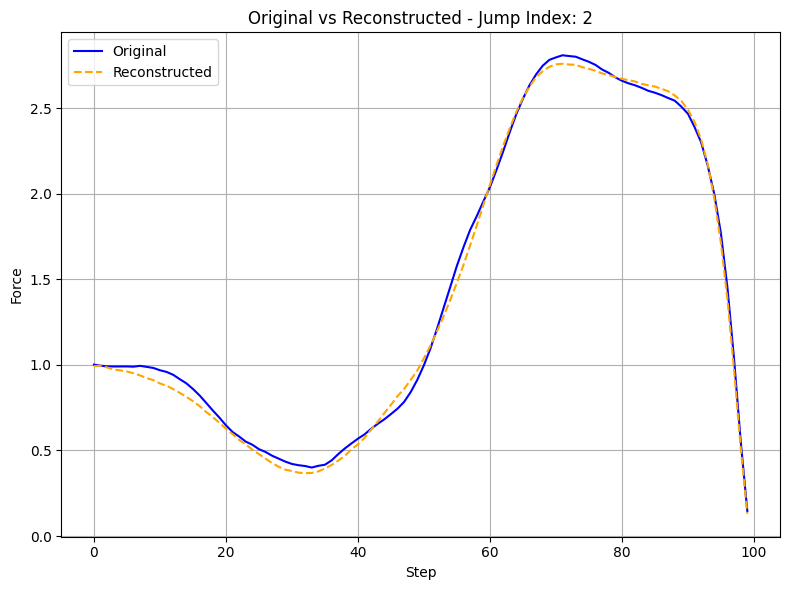

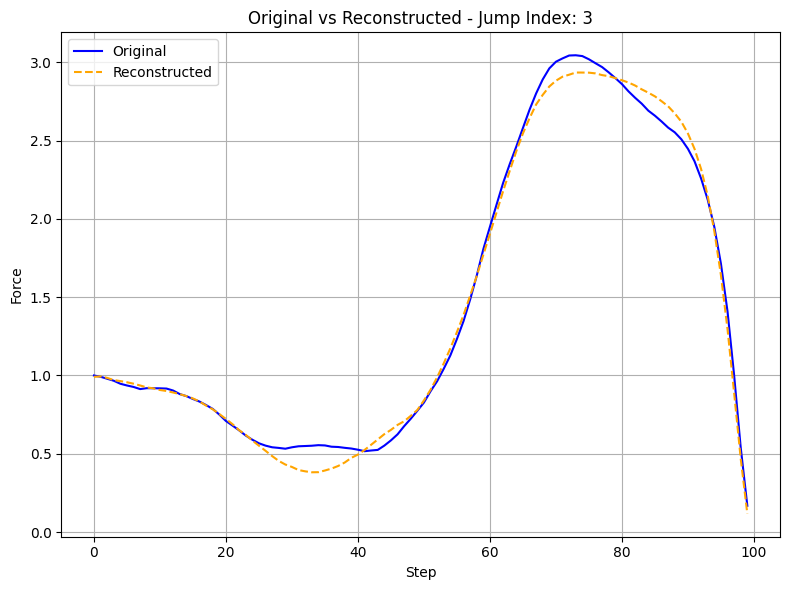

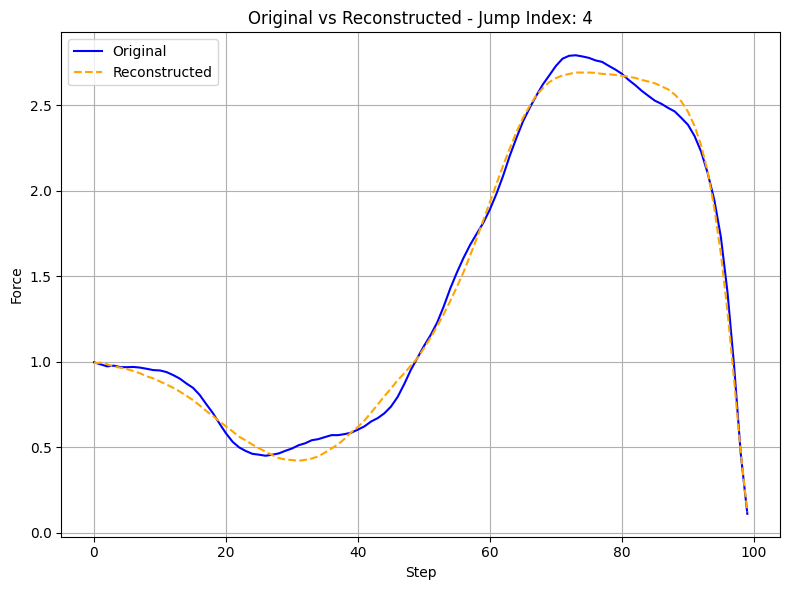

In [15]:
for i in range(5):
    plot_single_reconstruction(vae, downsampled_tensor, index=i)


In [16]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,normalized_time_series,downsampled_time_series,latent_space,latent_space_consistency,reconstruction_loss,outlier,initial_weight,vae_latent_space,vae_latent_space_2d,vae_latent_space_4d
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[1.0, 1.0, 0.994224553050578, 0.99422455305057...","[0.9997689723968506, 0.9933004975318909, 0.982...","[2.717329740524292, 1.7964253425598145, 0.9758...",0.309237,0.001501,0,519.440318,"[-0.024824915, -0.05880911, -0.0632134, 0.1535...","[0.45923862, 0.5638069, 1.921875, 0.08312285]","[-1.4384215, -0.39123285, 1.3975654, -0.08769328]"


In [88]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

sampled_df = data.sample(n=20000, random_state=42)

X_latent_4d = np.stack(sampled_df["vae_latent_space_4d"].values)
X_df = pd.DataFrame(X_latent_4d, columns=["Latent1", "Latent2", "Latent3", "Latent4"]).reset_index(drop=True)

y = sampled_df["JUMP_HEIGHT_INCHES"].reset_index(drop=True)

X_with_const = sm.add_constant(X_df)

model = sm.OLS(y, X_with_const).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     JUMP_HEIGHT_INCHES   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.310
Date:                Mon, 07 Apr 2025   Prob (F-statistic):             0.0102
Time:                        23:37:43   Log-Likelihood:                -55418.
No. Observations:               20000   AIC:                         1.108e+05
Df Residuals:                   19995   BIC:                         1.109e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.0095      0.027    585.696      0.0

In [97]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,vae_latent_space_2d,vae_latent_space_4d,curve_cluster,similarity_to_best,weight_bin,jump_height_bin,year,start_year,training_year,vae_latent_space_=2d
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[0.45923862, 0.5638069, 1.921875, 0.08312285]","[-1.4384215, -0.39123285, 1.3975654, -0.08769328]",0,3.250769,Bin 1,Bin 2,2023,2023,1,"[0.45923862, 0.5638069, 1.921875, 0.08312285]"


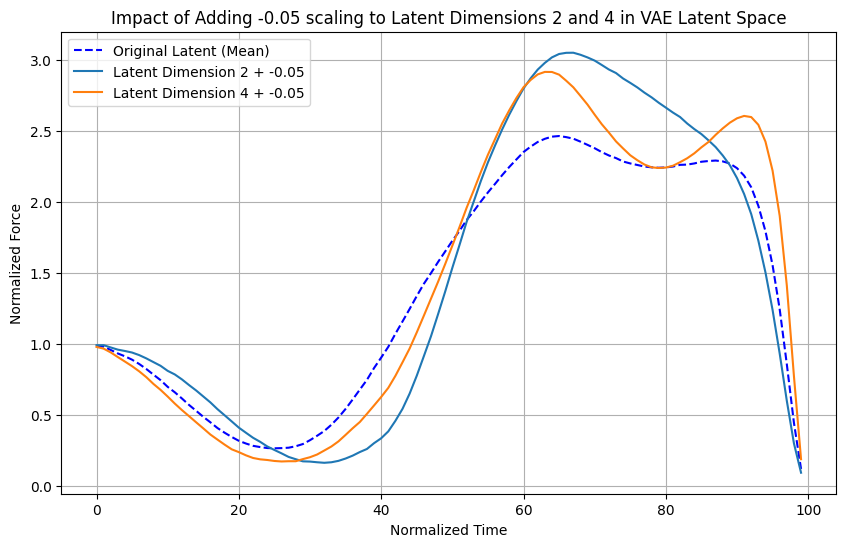

In [133]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Assuming vae_latent_space_4d is a numpy array of shape (n_samples, 4)
mean_tensor = torch.tensor(np.mean(data["vae_latent_space_4d"], axis=0)).float()

# Initialize scaling factors for each latent dimension (adding 1)
scaling_factor = -0.05

# Create the modified latent vectors by adding 1 to each latent dimension one by one
modified_latents = []
for i in [1, 3]:  # Only for latent dimensions 2 and 4 (index 1 and 3)
    modified_latent = mean_tensor.clone()  # Start with the mean
    modified_latent[i] += scaling_factor  # Add 1 to the i-th latent dimension
    modified_latents.append(modified_latent)

# Reconstruct the original and modified latent vectors
original_reconstruction = vae.decode(mean_tensor.unsqueeze(0)).detach().cpu().numpy()[0]
reconstructed_latents = []
for modified_latent in modified_latents:
    reconstruction = vae.decode(modified_latent.unsqueeze(0)).detach().cpu().numpy()[0]
    reconstructed_latents.append(reconstruction)

# Plot the original and modified reconstructions
plt.figure(figsize=(10, 6))

# Plot the original reconstruction
plt.plot(original_reconstruction, label="Original Latent (Mean)", linestyle="--", color="blue")

# Plot the modified reconstructions for latent dimensions 2 and 4
for i, reconstructed_latent in enumerate(reconstructed_latents):
    plt.plot(reconstructed_latent, label=f"Latent Dimension {i*2+2} + {scaling_factor}", linestyle="-")

# Formatting the plot
plt.xlabel("Normalized Time")
plt.ylabel("Normalized Force")
plt.title(f"Impact of Adding {scaling_factor} scaling to Latent Dimensions 2 and 4 in VAE Latent Space")
plt.legend()
plt.grid(True)
plt.show()


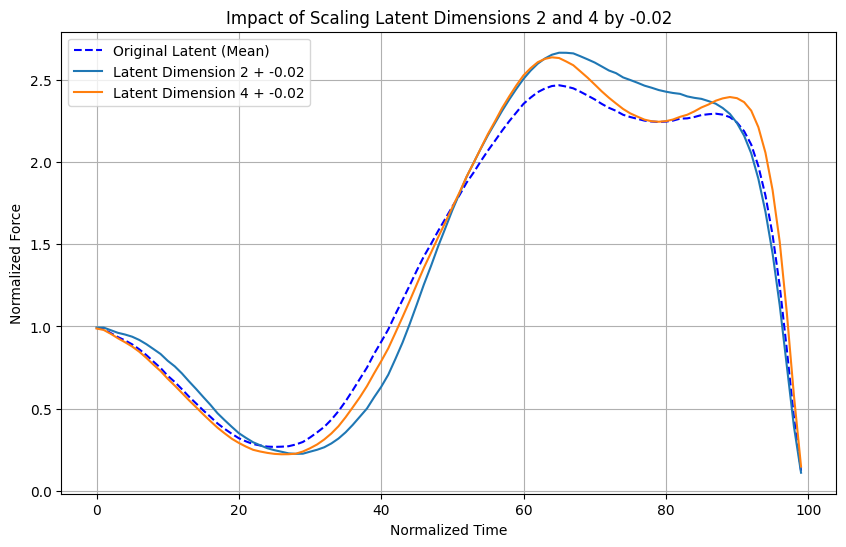

In [120]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Assuming vae_latent_space_4d is a numpy array of shape (n_samples, 4)
mean_tensor = torch.tensor(np.mean(data["vae_latent_space_4d"], axis=0)).float()

# Initialize the VAE and other necessary parts
def plot_reconstruction(scaling_factor):
    # Create the modified latent vectors by adding the scaling factor to each latent dimension
    modified_latents = []
    for i in [1, 3]:  # Only for latent dimensions 2 and 4 (index 1 and 3)
        modified_latent = mean_tensor.clone()  # Start with the mean
        modified_latent[i] += scaling_factor  # Add the scaling factor to the i-th latent dimension
        modified_latents.append(modified_latent)

    # Reconstruct the original and modified latent vectors
    original_reconstruction = vae.decode(mean_tensor.unsqueeze(0)).detach().cpu().numpy()[0]
    reconstructed_latents = []
    for modified_latent in modified_latents:
        reconstruction = vae.decode(modified_latent.unsqueeze(0)).detach().cpu().numpy()[0]
        reconstructed_latents.append(reconstruction)

    # Plot the original and modified reconstructions
    plt.figure(figsize=(10, 6))

    # Plot the original reconstruction
    plt.plot(original_reconstruction, label="Original Latent (Mean)", linestyle="--", color="blue")

    # Plot the modified reconstructions for latent dimensions 2 and 4
    for i, reconstructed_latent in enumerate(reconstructed_latents):
        plt.plot(reconstructed_latent, label=f"Latent Dimension {i*2+2} + {scaling_factor}", linestyle="-")

    # Formatting the plot
    plt.xlabel("Normalized Time")
    plt.ylabel("Normalized Force")
    plt.title(f"Impact of Scaling Latent Dimensions 2 and 4 by {scaling_factor}")
    plt.legend()
    plt.grid(True)
    plt.show()

# Create an interactive slider for scaling factor
scaling_factor_slider = widgets.FloatSlider(
    value=-0.02,  # Initial value
    min=-0.1,     # Minimum value
    max=0.1,      # Maximum value
    step=0.01,    # Step size
    description='Scaling Factor:',
    continuous_update=False  # Set to False to update only when the user releases the slider
)

# Link the slider to the plot function
widgets.interactive(plot_reconstruction, scaling_factor=scaling_factor_slider)


### Clustering Curve Types


In [18]:
latent_matrix_4d = np.stack(data["vae_latent_space_4d"].values)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
latent_scaled_4d = scaler.fit_transform(latent_matrix_4d)


In [21]:
from sklearn.cluster import KMeans

k = 4  
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(latent_scaled_4d)


In [22]:
data["curve_cluster"] = cluster_labels


In [24]:
def plot_average_curves(data_tensor, cluster_labels, cluster_id):
    indices = np.where(cluster_labels == cluster_id)[0]
    curves = data_tensor[indices].cpu().numpy()
    avg_curve = curves.mean(axis=0)
    
    plt.plot(avg_curve, label=f"Cluster {cluster_id}")
    plt.title(f"Average Force Curve - Cluster {cluster_id}")
    plt.xlabel("Step")
    plt.ylabel("Force")
    plt.grid(True)
    plt.legend()
    plt.show()


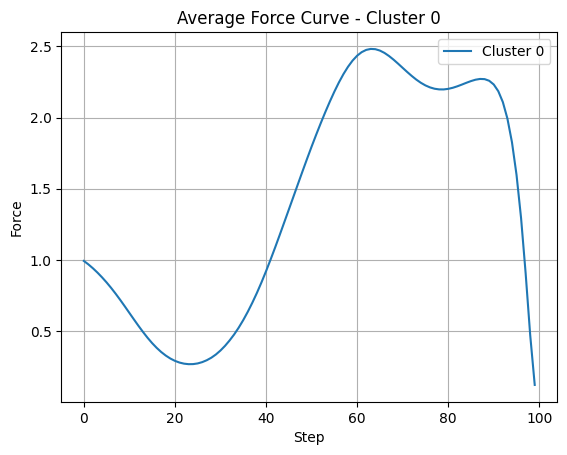

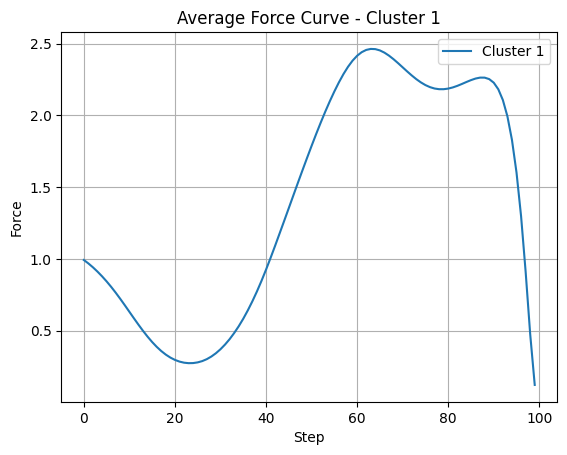

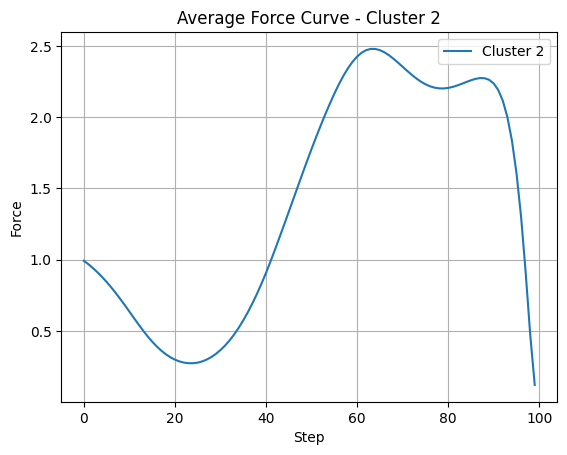

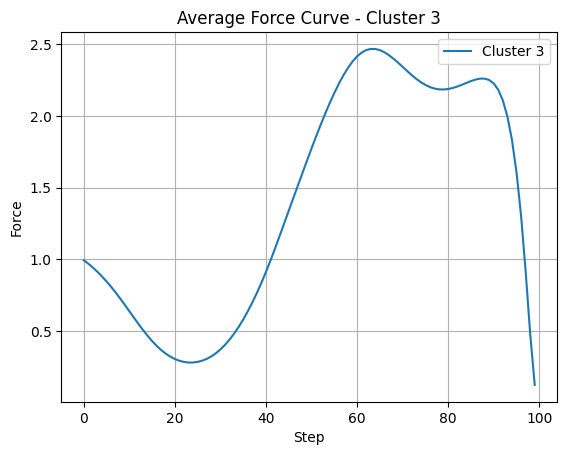

In [27]:
for c in np.unique(cluster_labels):
    plot_average_curves(downsampled_tensor, cluster_labels, c)


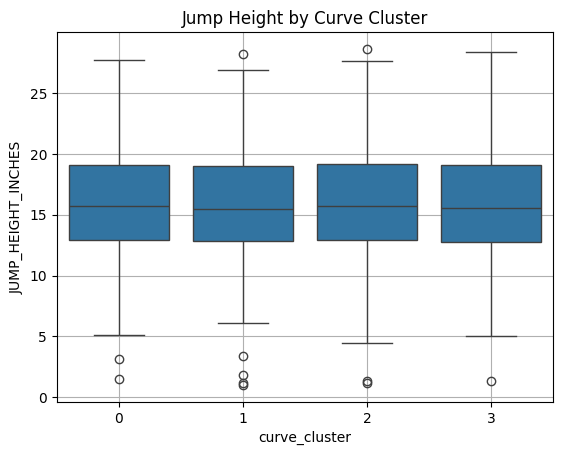

In [26]:
sns.boxplot(x="curve_cluster", y="JUMP_HEIGHT_INCHES", data=data)
plt.title("Jump Height by Curve Cluster")
plt.grid(True)
plt.show()


In [28]:
# Pick top 1% highest jump
top_jump = data.loc[data["JUMP_HEIGHT_INCHES"].idxmax()]
target_vector = np.array(top_jump["vae_latent_space_4d"]).reshape(1, -1)


In [29]:
from sklearn.metrics.pairwise import euclidean_distances

all_vectors = np.stack(data["vae_latent_space_4d"].values)
distances = euclidean_distances(target_vector, all_vectors).flatten()


In [30]:
data["similarity_to_best"] = distances
most_similar = data.nsmallest(10, "similarity_to_best")  # top 10 most similar


In [31]:
def plot_similar_curves(original_index, similar_indices, tensor):
    plt.figure(figsize=(12, 6))
    
    original_curve = tensor[original_index].cpu().numpy()
    plt.plot(original_curve, label=f"Original (idx {original_index})", linewidth=3, color='black')

    for idx in similar_indices:
        curve = tensor[idx].cpu().numpy()
        plt.plot(curve, alpha=0.5, linestyle='--')

    plt.title("Original Jump vs Similar Jumps (Based on VAE Latent Space)")
    plt.xlabel("Step")
    plt.ylabel("Force")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


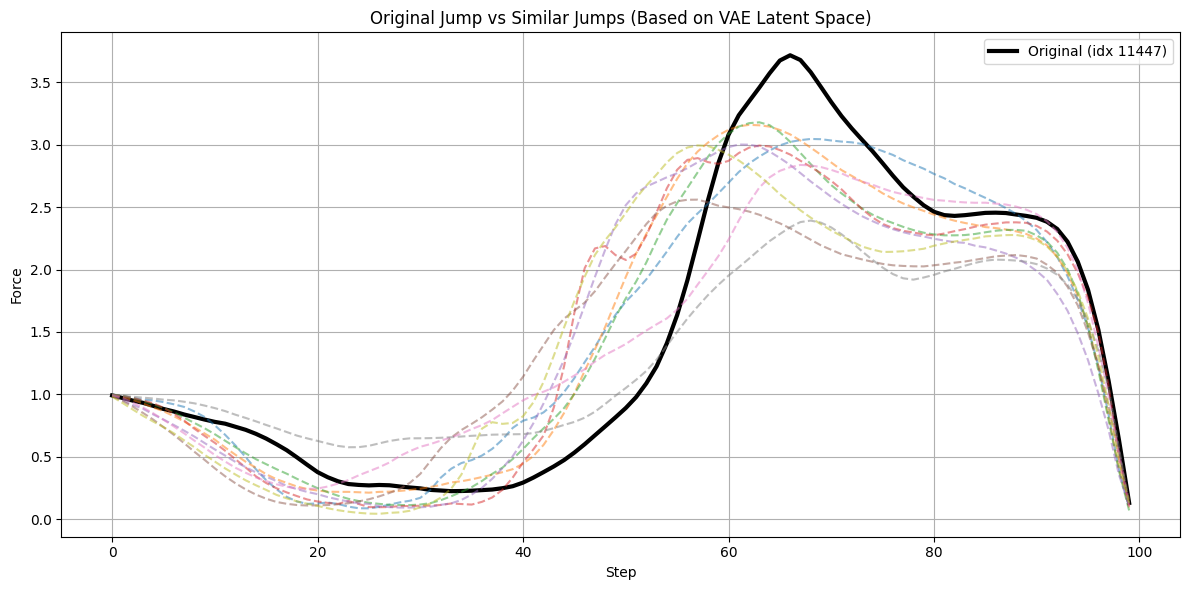

In [34]:
# Get actual position in the DataFrame
original_tensor_idx = data.index.get_loc(original_idx)
similar_tensor_idxs = [data.index.get_loc(i) for i in similar_idxs]
plot_similar_curves(original_tensor_idx, similar_tensor_idxs, downsampled_tensor)


In [33]:
most_similar[["JUMP_HEIGHT_INCHES", "similarity_to_best"]].sort_values("similarity_to_best")


,JUMP_HEIGHT_INCHES,similarity_to_best
12554,28.614006,0.000000
2713,18.791714,0.289594
14498,13.556543,0.361483
4486,20.515986,0.365425
13124,21.535261,0.365467
29943,13.454422,0.367645
28229,15.188781,0.368916
5708,19.767746,0.375826
8433,16.347192,0.389404
17452,18.791714,0.389503


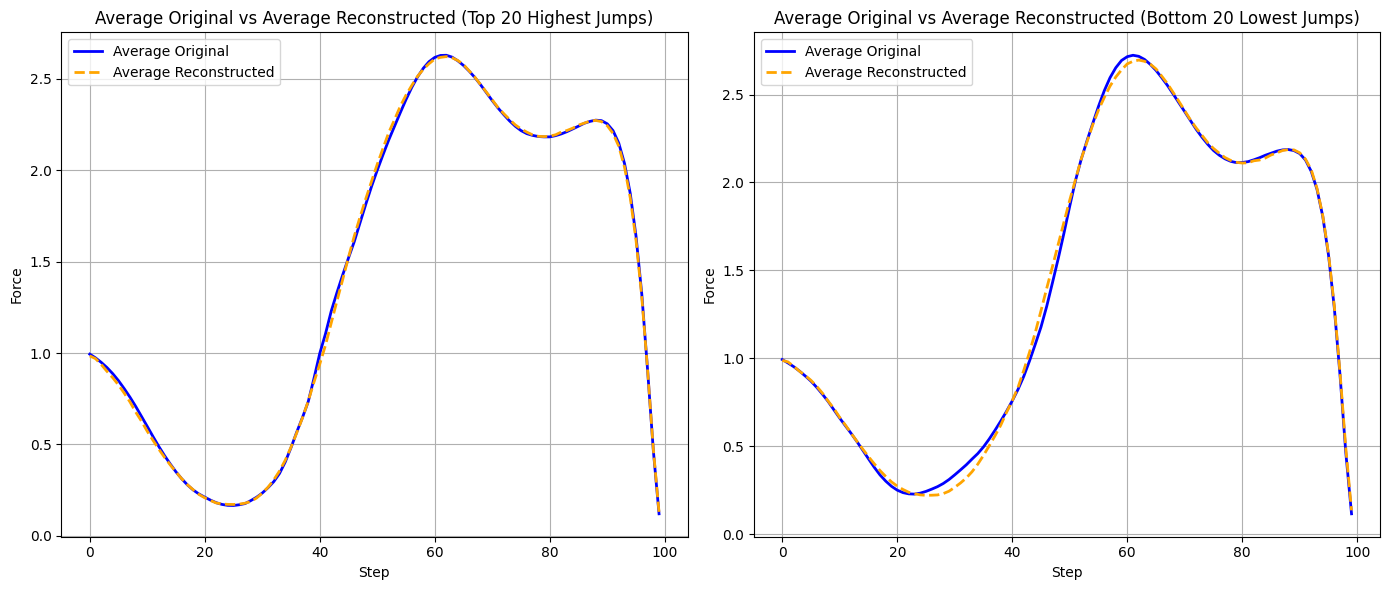

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def plot_average_reconstruction_comparison(vae, data_tensor, jump_height_column="JUMP_HEIGHT_INCHES", top_n=20):
    # Sort the data based on jump height for highest and lowest jumps
    top_jumps = data.sort_values(by=jump_height_column, ascending=False).head(top_n)
    lowest_jumps = data.sort_values(by=jump_height_column, ascending=True).head(top_n)
    
    # Get the indices of the top and lowest jumps
    top_jump_indices = top_jumps.index
    lowest_jump_indices = lowest_jumps.index
    
    # Ensure indices are within the bounds of data_tensor
    top_jump_indices = [i for i in top_jump_indices if i < len(data_tensor)]
    lowest_jump_indices = [i for i in lowest_jump_indices if i < len(data_tensor)]

    # Initialize arrays to store the original and reconstructed curves
    original_top_curves = []
    reconstructed_top_curves = []
    original_low_curves = []
    reconstructed_low_curves = []

    # Get the original and reconstructed curves for the top N highest jumps
    for original_index in top_jump_indices:
        original_curve = data_tensor[original_index].cpu().numpy()
        original_top_curves.append(original_curve)
        vae.eval()
        with torch.no_grad():
            x = data_tensor[original_index].unsqueeze(0)  # Add batch dimension
            x_hat, _, _ = vae(x)
            reconstructed_curve = x_hat.squeeze().cpu().numpy()
        reconstructed_top_curves.append(reconstructed_curve)

    # Get the original and reconstructed curves for the bottom N lowest jumps
    for original_index in lowest_jump_indices:
        original_curve = data_tensor[original_index].cpu().numpy()
        original_low_curves.append(original_curve)
        vae.eval()
        with torch.no_grad():
            x = data_tensor[original_index].unsqueeze(0)  # Add batch dimension
            x_hat, _, _ = vae(x)
            reconstructed_curve = x_hat.squeeze().cpu().numpy()
        reconstructed_low_curves.append(reconstructed_curve)

    # Compute the average of the curves
    avg_original_top_curve = np.mean(original_top_curves, axis=0)
    avg_reconstructed_top_curve = np.mean(reconstructed_top_curves, axis=0)
    avg_original_low_curve = np.mean(original_low_curves, axis=0)
    avg_reconstructed_low_curve = np.mean(reconstructed_low_curves, axis=0)

    # Create a subplot with 2 plots side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot for the top highest jumps
    axes[0].plot(avg_original_top_curve, label="Average Original", color="blue", linewidth=2)
    axes[0].plot(avg_reconstructed_top_curve, label="Average Reconstructed", color="orange", linestyle="--", linewidth=2)
    axes[0].set_title(f"Average Original vs Average Reconstructed (Top {top_n} Highest Jumps)")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Force")
    axes[0].legend()
    axes[0].grid(True)

    # Plot for the bottom lowest jumps
    axes[1].plot(avg_original_low_curve, label="Average Original", color="blue", linewidth=2)
    axes[1].plot(avg_reconstructed_low_curve, label="Average Reconstructed", color="orange", linestyle="--", linewidth=2)
    axes[1].set_title(f"Average Original vs Average Reconstructed (Bottom {top_n} Lowest Jumps)")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Force")
    axes[1].legend()
    axes[1].grid(True)

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Call the function to plot the average of the highest and lowest jumps side by side
plot_average_reconstruction_comparison(vae, downsampled_tensor)


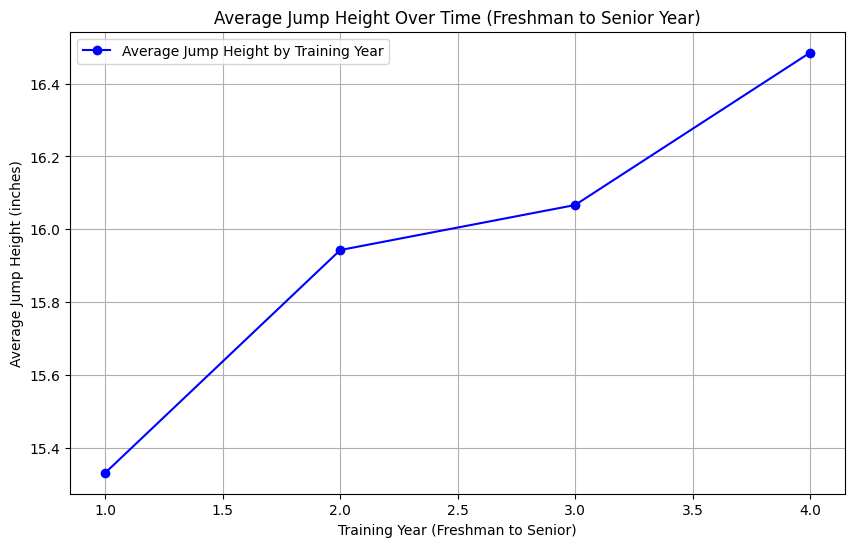

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'recordedUTC' is in datetime format
data['year'] = pd.to_datetime(data['recordedUTC']).dt.year

# Step 1: Group by profileID and year to calculate average jump height per year
average_jump_height_per_year = data.groupby(['profileID', 'year'])['JUMP_HEIGHT_INCHES'].mean().reset_index()

# Step 2: Create a column for the training year (freshman, sophomore, etc.) for each profileID
# Sort the data by profileID and year
average_jump_height_per_year = average_jump_height_per_year.sort_values(by=['profileID', 'year'])

# Calculate the training year based on the first year of each profileID
average_jump_height_per_year['training_year'] = average_jump_height_per_year.groupby('profileID')['year'].transform('min')
average_jump_height_per_year['training_year'] = average_jump_height_per_year['year'] - average_jump_height_per_year['training_year'] + 1

# Step 3: Filter out profiles with fewer than 4 years of data (if needed)
valid_profiles = average_jump_height_per_year.groupby('profileID').filter(lambda x: len(x) >= 2)

# Step 4: Compute the average jump height per training year across all valid profiles
avg_jump_height_per_training_year = valid_profiles.groupby(['training_year'])['JUMP_HEIGHT_INCHES'].mean()

# Step 5: Plot the average jump height for each training year
plt.figure(figsize=(10, 6))
plt.plot(avg_jump_height_per_training_year.index, avg_jump_height_per_training_year, label='Average Jump Height by Training Year', color='blue', marker='o')
plt.title("Average Jump Height Over Time (Freshman to Senior Year)")
plt.xlabel("Training Year (Freshman to Senior)")
plt.ylabel("Average Jump Height (inches)")
plt.legend()
plt.grid(True)
plt.show()


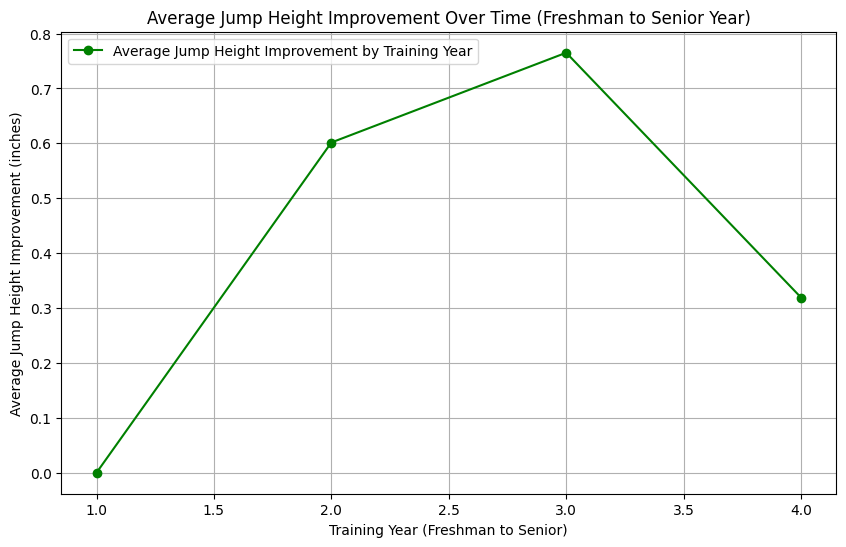

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'recordedUTC' is in datetime format
data['year'] = pd.to_datetime(data['recordedUTC']).dt.year

# Step 1: Group by profileID and year to calculate average jump height per year
average_jump_height_per_year = data.groupby(['profileID', 'year'])['JUMP_HEIGHT_INCHES'].mean().reset_index()

# Step 2: Sort the data by profileID and year
average_jump_height_per_year = average_jump_height_per_year.sort_values(by=['profileID', 'year'])

# Step 3: Calculate the training year for each profileID
average_jump_height_per_year['training_year'] = average_jump_height_per_year.groupby('profileID')['year'].transform('min')
average_jump_height_per_year['training_year'] = average_jump_height_per_year['year'] - average_jump_height_per_year['training_year'] + 1

# Step 4: Filter out profiles with fewer than 2 years of data
valid_profiles = average_jump_height_per_year.groupby('profileID').filter(lambda x: len(x) >= 2)

# Step 5: Calculate jump height improvement for each profileID
valid_profiles['jump_height_improvement'] = valid_profiles.groupby('profileID')['JUMP_HEIGHT_INCHES'].diff().fillna(0)

# Step 6: Group by training year and calculate the average improvement for each year
avg_improvement_per_training_year = valid_profiles.groupby('training_year')['jump_height_improvement'].mean()

# Step 7: Plot the average jump height improvement per training year
plt.figure(figsize=(10, 6))
plt.plot(avg_improvement_per_training_year.index, avg_improvement_per_training_year, label='Average Jump Height Improvement by Training Year', color='green', marker='o')
plt.title("Average Jump Height Improvement Over Time (Freshman to Senior Year)")
plt.xlabel("Training Year (Freshman to Senior)")
plt.ylabel("Average Jump Height Improvement (inches)")
plt.legend()
plt.grid(True)
plt.show()


In [83]:
valid_profiles

,profileID,year,JUMP_HEIGHT_INCHES,training_year,jump_height_improvement
0,005d3292-4437-4838-b342-0bc4d650b843,2023,13.231750,1,0.000000
1,005d3292-4437-4838-b342-0bc4d650b843,2024,14.048905,2,0.817155
2,005d3292-4437-4838-b342-0bc4d650b843,2025,15.975518,3,1.926613
3,00a9267d-65b5-44b8-adbf-586c8e5412cd,2022,17.275692,1,0.000000
4,00a9267d-65b5-44b8-adbf-586c8e5412cd,2023,17.079365,2,-0.196327
...,...,...,...,...,...
1384,fe75710b-1e78-46df-a458-5ad06622e76a,2025,14.165894,3,0.045118
1385,ff218290-61dd-44fa-98ec-1db80d58a01d,2024,14.130612,1,0.000000
1386,ff218290-61dd-44fa-98ec-1db80d58a01d,2025,15.699947,2,1.569335
1387,ff4218a5-c3aa-47d1-a2a7-21b406890a72,2023,11.391485,1,0.000000


In [67]:
average_jump_height_per_year

,profileID,year,JUMP_HEIGHT_INCHES,training_year
0,005d3292-4437-4838-b342-0bc4d650b843,2023,13.231750,1
1,005d3292-4437-4838-b342-0bc4d650b843,2024,14.048905,2
2,005d3292-4437-4838-b342-0bc4d650b843,2025,15.975518,3
3,00a9267d-65b5-44b8-adbf-586c8e5412cd,2022,17.275692,1
4,00a9267d-65b5-44b8-adbf-586c8e5412cd,2023,17.079365,2
...,...,...,...,...
1384,fe75710b-1e78-46df-a458-5ad06622e76a,2025,14.165894,3
1385,ff218290-61dd-44fa-98ec-1db80d58a01d,2024,14.130612,1
1386,ff218290-61dd-44fa-98ec-1db80d58a01d,2025,15.699947,2
1387,ff4218a5-c3aa-47d1-a2a7-21b406890a72,2023,11.391485,1


In [73]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,vae_latent_space,vae_latent_space_2d,vae_latent_space_4d,curve_cluster,similarity_to_best,weight_bin,jump_height_bin,year,start_year,training_year
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[-0.024824915, -0.05880911, -0.0632134, 0.1535...","[0.45923862, 0.5638069, 1.921875, 0.08312285]","[-1.4384215, -0.39123285, 1.3975654, -0.08769328]",0,3.250769,Bin 1,Bin 2,2023,2023,1


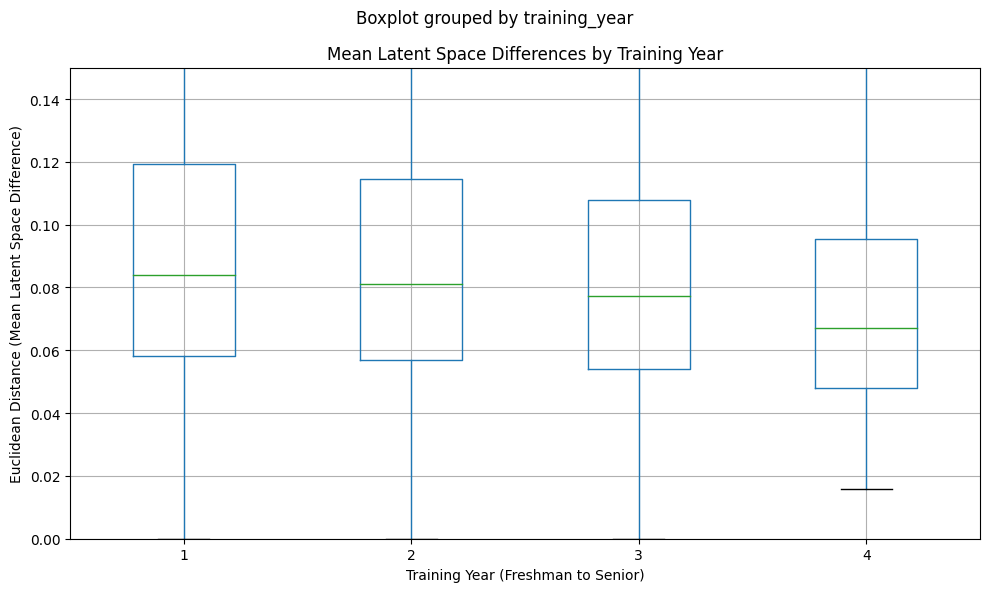

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

data['recordedUTC'] = pd.to_datetime(data['recordedUTC'], errors='coerce')
data['year'] = pd.to_datetime(data['recordedUTC']).dt.year

data['start_year'] = data.groupby('profileID')['recordedUTC'].transform('min').dt.year
data['training_year'] = data['year'] - data['start_year'] + 1

# Step 2: Filter valid profiles (those with at least 2 years of data)
valid_profiles = data.groupby('profileID').filter(lambda x: len(x) >= 2)

# Step 3: Calculate latent space differences for each profile's training year
data['vae_latent_space'] = data['vae_latent_space'].apply(np.array)  # Ensure latent space is in correct format

latent_space_differences = []

for profile_id, profile_data in valid_profiles.groupby('profileID'):
    for training_year, year_data in profile_data.groupby('training_year'):
        
        latent_vectors = torch.tensor(np.stack(year_data['vae_latent_space'].values), dtype=torch.float32)
        
        # Calculate the mean latent space vector for this year
        mean_latent = latent_vectors.mean(dim=0)
        
        # Compute the Euclidean distance between each latent vector and the mean
        differences = torch.norm(latent_vectors - mean_latent, dim=1).numpy()  # Euclidean distance
        
        # Store the results
        for diff, (_, row) in zip(differences, year_data.iterrows()):
            latent_space_differences.append({
                'profileID': profile_id, 
                'training_year': training_year, 
                'difference': diff
            })

# Step 4: Create a DataFrame from the results
diff_df = pd.DataFrame(latent_space_differences)

# Step 5: Plot the differences by training year (boxplot)
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)
diff_df.boxplot(column='difference', by='training_year', ax=ax)
ax.set_ylim(0, .15)
ax.set_title("Mean Latent Space Differences by Training Year")
ax.set_xlabel("Training Year (Freshman to Senior)")
ax.set_ylabel("Euclidean Distance (Mean Latent Space Difference)")
ax.grid(True)


plt.tight_layout()
plt.show()


In [84]:
data.head(1)

,Unnamed: 0.1,Unnamed: 0,testID,rep,profileID,recordedUTC,Team,Category,BODY_WEIGHT_N,BODY_WEIGHT,...,vae_latent_space_2d,vae_latent_space_4d,curve_cluster,similarity_to_best,weight_bin,jump_height_bin,year,start_year,training_year,vae_latent_space_=2d
0,0,0,f6b0b4f3-ccaa-488c-b71b-2a9d6fd8c359,1,eb037fd9-1b41-4bee-ade5-079f3d3012f8,2023-01-06 23:31:43.937000+00:00,Acro and Tumbling,Sport,NaN,NaN,...,"[0.45923862, 0.5638069, 1.921875, 0.08312285]","[-1.4384215, -0.39123285, 1.3975654, -0.08769328]",0,3.250769,Bin 1,Bin 2,2023,2023,1,"[0.45923862, 0.5638069, 1.921875, 0.08312285]"
